In [27]:
!git clone https://github.com/antisocialites/Deep-Learning.git

Cloning into 'Deep-Learning'...
remote: Enumerating objects: 246, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 246 (delta 7), reused 25 (delta 5), pack-reused 217 (from 1)
Receiving objects: 100% (246/246), 41.22 MiB | 25.86 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [28]:
!pwd

/content/Deep-Learning/Assignment 2


In [29]:
%cd 'Deep-Learning/Assignment 2'
!ls
import sys
sys.path.append('.')  # C

/content/Deep-Learning/Assignment 2/Deep-Learning/Assignment 2
 All_Models			      clusters_subchunks.ipynb
 All_Models-seq.ipynb		      preprocessing_clusters.ipynb
 Attention			      Sensor_combinations.ipynb
 best_intra_cnnrnn_model.keras	     'subchunks without gridsearch.ipynb'
'clusters_subchunks - ankita.ipynb'   utils


In [30]:
import os
import glob
import re
import h5py
import numpy as np
import pandas as pd
import random
from typing import Tuple, Literal, Optional, List
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from scipy.signal import decimate
import matplotlib.pyplot as plt
import itertools
# For CNN/RNN
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, InputLayer
)
from tensorflow.keras.optimizers import Adam

from utils.preprocessing_utils import *
from utils.visual_utils import *
import gc
gc.collect()


785

In [31]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Training

## Intra Files

In [32]:
## TRAINING DATA ##

# intra 1
participant_id_intra = 105923
rest_intra, motor_intra, story_math_intra, wm_intra = load_participant_arrays(participant_id_intra, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Intra/train")


print("Rest:", None if rest_intra is None else rest_intra.shape)
print("Motor:", None if motor_intra is None else motor_intra.shape)
print("Story/Math:", None if story_math_intra is None else story_math_intra.shape)
print("Working Memory:", None if wm_intra is None else wm_intra.shape)


Rest: (248, 284992)
Motor: (248, 284992)
Story/Math: (248, 284992)
Working Memory: (248, 284992)


## Contra Files

In [33]:
## TRAINING DATA ##
'''
# contra 1
participant_id_c1 = 113922

#contra 2
participant_id_c2 = 164636


rest_c1, motor_c1, story_math_c1, wm_c1 = load_participant_arrays(participant_id_c1, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Cross/train")
rest_c2, motor_c2, story_math_c2, wm_c2 = load_participant_arrays(participant_id_c2, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Cross/train")


print("Rest:", None if rest_c2 is None else rest_c2.shape)
print("Motor:", None if motor_c2 is None else motor_c2.shape)
print("Story/Math:", None if story_math_c2 is None else story_math_c2.shape)
print("Working Memory:", None if wm_c2 is None else wm_c2.shape)'''

'\n# contra 1\nparticipant_id_c1 = 113922\n\n#contra 2\nparticipant_id_c2 = 164636\n\n\nrest_c1, motor_c1, story_math_c1, wm_c1 = load_participant_arrays(participant_id_c1, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Cross/train")\nrest_c2, motor_c2, story_math_c2, wm_c2 = load_participant_arrays(participant_id_c2, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Cross/train")\n\n\nprint("Rest:", None if rest_c2 is None else rest_c2.shape)\nprint("Motor:", None if motor_c2 is None else motor_c2.shape)\nprint("Story/Math:", None if story_math_c2 is None else story_math_c2.shape)\nprint("Working Memory:", None if wm_c2 is None else wm_c2.shape)'

## Training Intra

In [34]:
datasets = [rest_intra, motor_intra, story_math_intra, wm_intra]
task_names = ["rest", "motor", "story_math", "wm"]

# preprocessing all datasets
preprocessed_datasets=[]
norm_values = []
for data in datasets:
  arr, mean, std = preprocess_meg_data(
        data,
        scaling="zscore",
        downsample_method="decimate",
        target_rate=64,
        orig_rate=2034
    )
  preprocessed_datasets.append(arr)
  norm_values.append((mean, std))



# clustering using averaged cosine similarity
sensor_order, cluster_labels, avg_sim_matrix = cossim_cluster_multi_task(
    preprocessed_datasets,
    n_clusters=5
)

# reorder and store data per task
reordered_data_dict = {}
sensor_order_dict = {}
cluster_labels_dict = {}

for preproc_data, name in zip(preprocessed_datasets, task_names):
    reordered_data = preproc_data[sensor_order, :]
    reordered_data_dict[f"reordered_data_{name}"] = reordered_data
    sensor_order_dict[f"sensor_order_{name}"] = sensor_order
    cluster_labels_dict[f"cluster_labels_{name}"] = cluster_labels


In [35]:
# maybe not the most efficient way oops
rest_data = reordered_data_dict["reordered_data_rest"]
rest_sensor_order = sensor_order_dict["sensor_order_rest"]
rest_clusters = cluster_labels_dict["cluster_labels_rest"]

motor_data = reordered_data_dict["reordered_data_motor"]
motor_sensor_order = sensor_order_dict["sensor_order_motor"]
motor_clusters = cluster_labels_dict["cluster_labels_motor"]

story_math_data = reordered_data_dict["reordered_data_story_math"]
story_math_sensor_order = sensor_order_dict["sensor_order_story_math"]
story_math_clusters = cluster_labels_dict["cluster_labels_story_math"]

wm_data = reordered_data_dict["reordered_data_wm"]
wm_sensor_order = sensor_order_dict["sensor_order_wm"]
wm_clusters = cluster_labels_dict["cluster_labels_wm"]


### Data Visualization

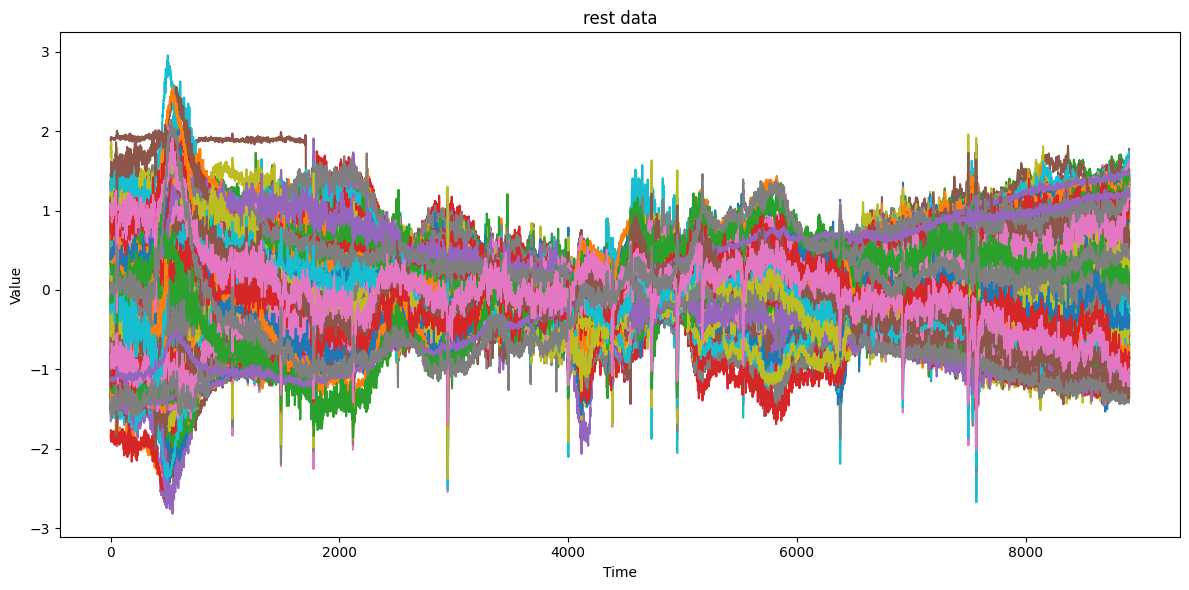

In [36]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(rest_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("rest data")
plt.tight_layout()
plt.show()

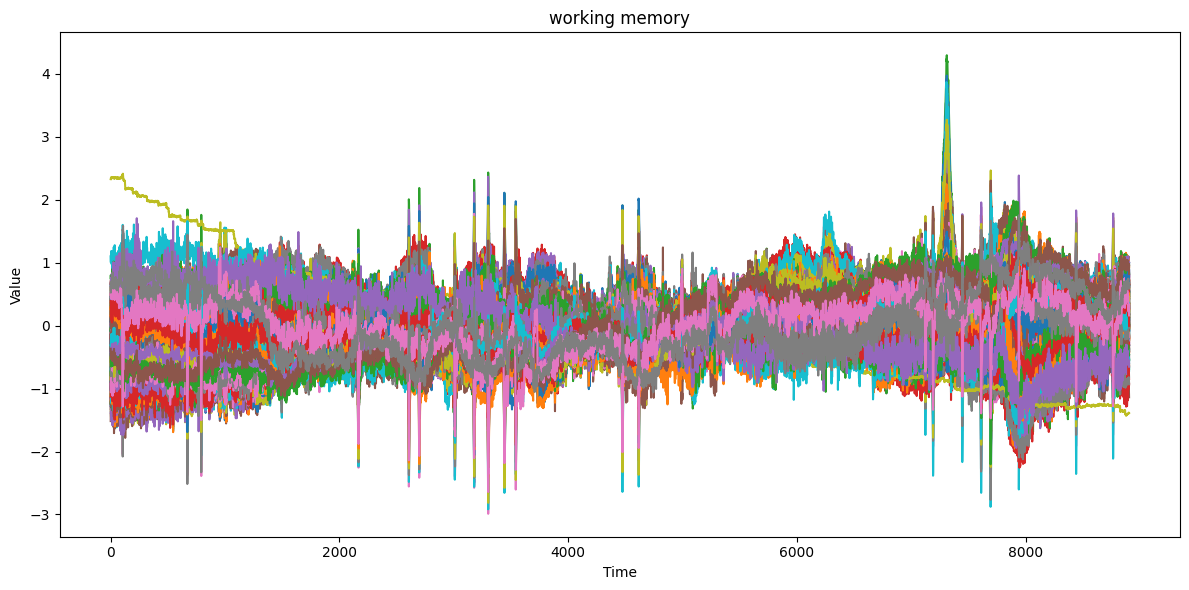

In [37]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(wm_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("working memory")
plt.tight_layout()
plt.show()

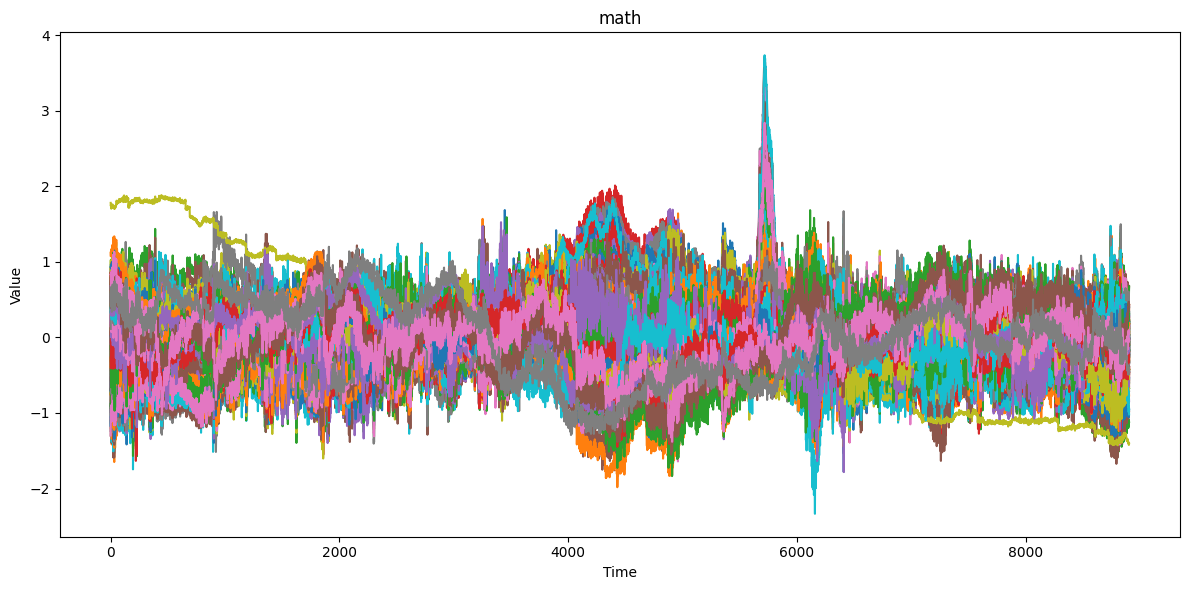

In [38]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(story_math_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("math")
plt.tight_layout()
plt.show()

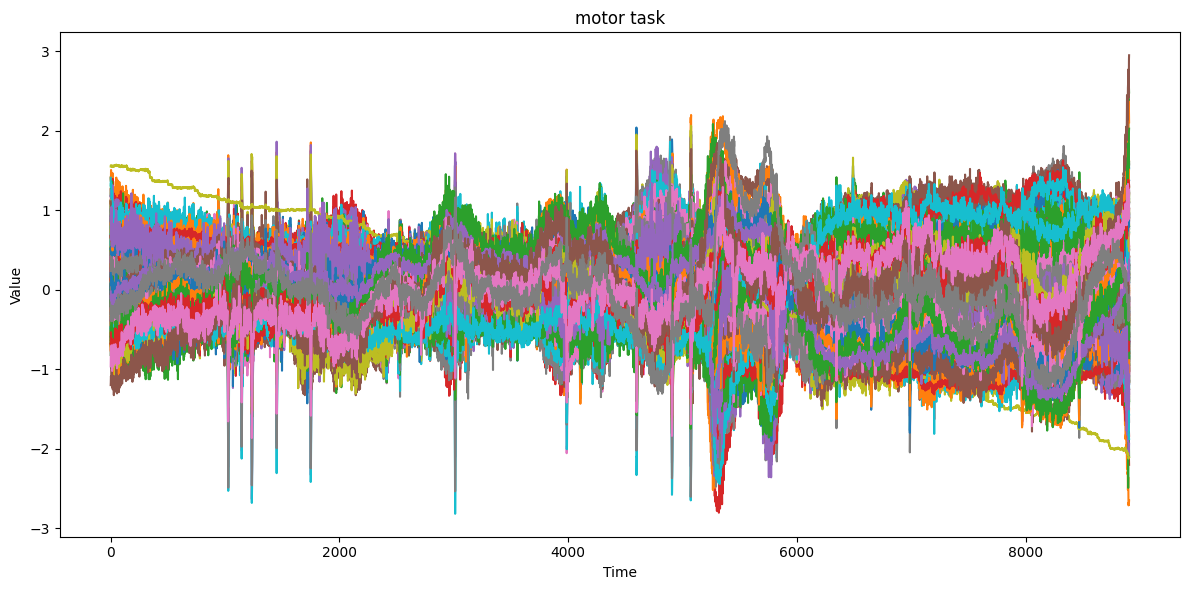

In [39]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(motor_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("motor task")
plt.tight_layout()
plt.show()

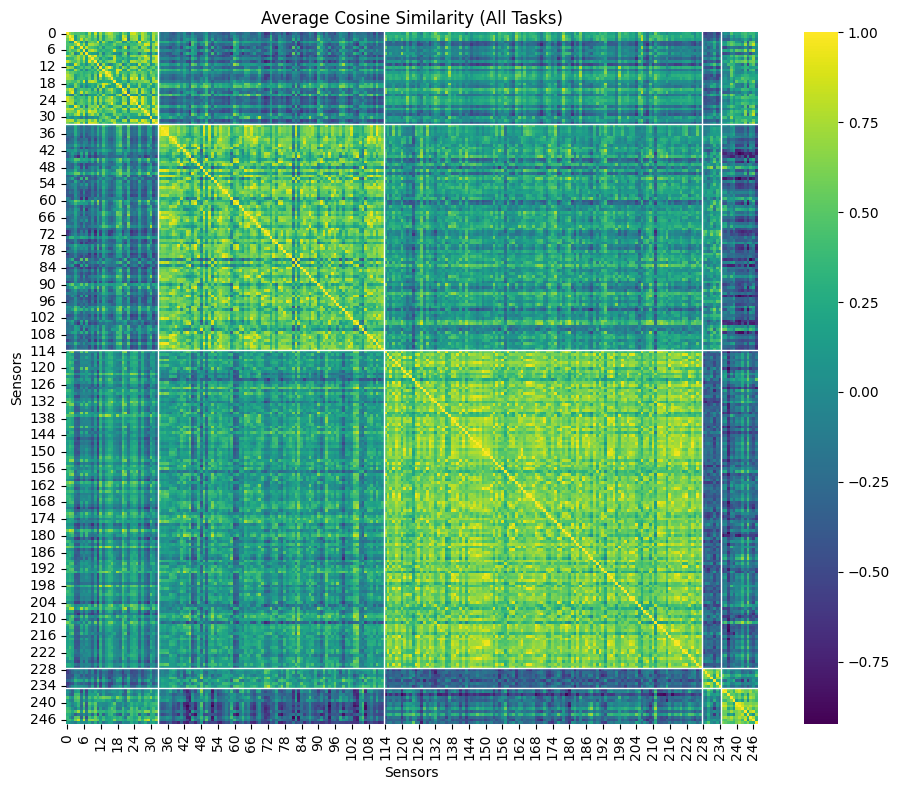

In [40]:
plot_avg_sensor_similarity(
    sim_matrix=avg_sim_matrix,
    sensor_order=sensor_order,
    cluster_labels=cluster_labels,
    title="Average Cosine Similarity (All Tasks)"
)

### Simple FFN

In [41]:
def extract_snapshots(data, time_per_snapshot=32, agg_func=np.mean, method='time'):
    """
    Extract 1s snapshots with time or space aggregation.
    """
    sensors, total_time = data.shape
    snapshots = []
    for start in range(0, total_time - time_per_snapshot + 1, time_per_snapshot):
        snap = data[:, start:start + time_per_snapshot]
        if method == 'time':
            agg = agg_func(snap, axis=1)
        else:
            agg = agg_func(snap, axis=0)
        snapshots.append(agg)
    return np.stack(snapshots)


### Aggregate the time dimension

In [42]:

label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

# Prepare snapshot-level dataset
X_rest = extract_snapshots(rest_data, method='time')
X_motor = extract_snapshots(motor_data, method='time')
X_story = extract_snapshots(story_math_data, method='time')
X_wm = extract_snapshots(wm_data, method='time')

y_rest = np.full((X_rest.shape[0],), label_map['rest'])
y_motor = np.full((X_motor.shape[0],), label_map['motor'])
y_story = np.full((X_story.shape[0],), label_map['story_math'])
y_wm = np.full((X_wm.shape[0],), label_map['wm'])

X_all = np.concatenate([X_rest, X_motor, X_story, X_wm])
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm])


# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [43]:
# Prepare data
# Build FFNN model
def build_ffnn(input_shape, dense_units=128, dropout_rate=0.3, num_classes=4):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(dense_units // 2, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Instantiate and compile
snapshot_model = build_ffnn(input_shape=(X_train.shape[1],))

snapshot_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
snapshot_history = snapshot_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5237 - loss: 1.1225 - val_accuracy: 0.9596 - val_loss: 0.3928
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8933 - loss: 0.4327 - val_accuracy: 0.9596 - val_loss: 0.1596
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9384 - loss: 0.2488 - val_accuracy: 1.0000 - val_loss: 0.0732
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9750 - loss: 0.1458 - val_accuracy: 0.9910 - val_loss: 0.0410
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9875 - loss: 0.0979 - val_accuracy: 1.0000 - val_loss: 0.0204
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9854 - loss: 0.0722 - val_accuracy: 1.0000 - val_loss: 0.0123
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9797 - loss: 0.0652 - val_accuracy: 1.0000 - val_loss: 0.0094
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9922 - loss: 0.0448 - val_accuracy: 1.0000 - val_loss:

In [44]:
# Show model summary
snapshot_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,166 (473.31 KB)

 Trainable params: 40,388 (157.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 80,778 (315.54 KB)

In [45]:
snapshot_model.save("snapshot_model.h5")
from google.colab import files
files.download("snapshot_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

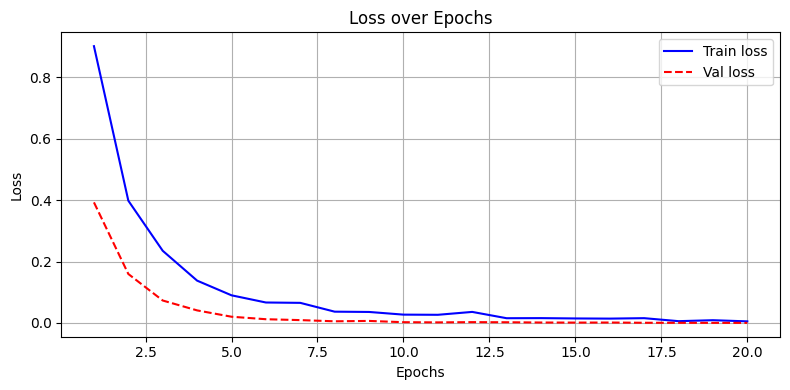

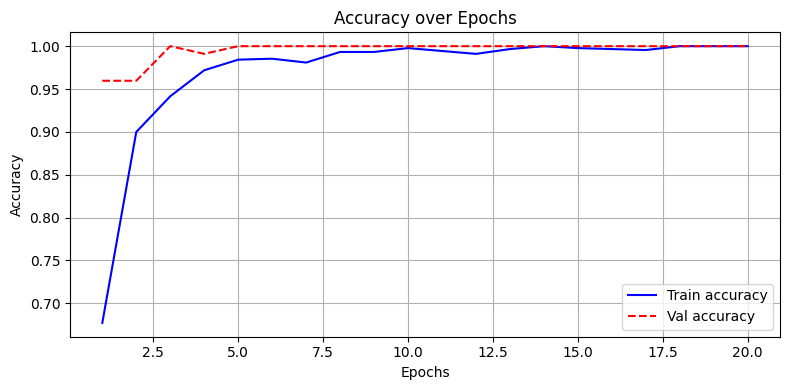

In [46]:
plot_training_history(snapshot_history, metrics=['loss', 'accuracy'])

In [47]:
from scipy.stats import mode

def predict_full_sequence(model, data, method='time', time_per_snapshot=32, agg='mean'):
    snapshots = extract_snapshots(data, time_per_snapshot, method=method)
    snapshots = np.asarray(snapshots)  # Ensure it's a proper ndarray
    probs = model.predict(snapshots)   # Shape: (num_snapshots, num_classes)

    if agg == 'mean':
        return int(np.argmax(np.mean(probs, axis=0)))
    elif agg == 'vote':
        preds = np.argmax(probs, axis=1)
        return int(mode(preds).mode[0])
    else:
        raise ValueError("Unsupported aggregation method.")



In [48]:
X_sequences = [rest_data, motor_data, story_math_data, wm_data]
y_true = [0, 1, 2, 3]  # true labels corresponding to above

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


y_pred = [predict_full_sequence(snapshot_model, seq, method = 'time') for seq in X_sequences]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Snapshot validation accuracy:", snapshot_model.evaluate(X_val, y_val)[1])
print("Sequence aggregated accuracy:", accuracy_score(y_true, y_pred))

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        rest       1.00      1.00      1.00         1
       motor       1.00      1.00      1.00         1
  story_math       1.00      1.00      1.00         1
          wm       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix:
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 3.9167e-04 
Snapshot validation accuracy: 1.0
Sequence aggregated accuracy: 1.0


### Aggregate the space dimension

In [49]:

label_map = {
    "rest": 0,
    "motor": 1,
    "story_math": 2,
    "wm": 3
}

# Prepare snapshot-level dataset
X_rest = extract_snapshots(rest_data, method='space')
X_motor = extract_snapshots(motor_data, method='space')
X_story = extract_snapshots(story_math_data, method='space')
X_wm = extract_snapshots(wm_data, method='space')

y_rest = np.full((X_rest.shape[0],), label_map['rest'])
y_motor = np.full((X_motor.shape[0],), label_map['motor'])
y_story = np.full((X_story.shape[0],), label_map['story_math'])
y_wm = np.full((X_wm.shape[0],), label_map['wm'])

X_all = np.concatenate([X_rest, X_motor, X_story, X_wm])
y_all = np.concatenate([y_rest, y_motor, y_story, y_wm])


# shuffle??
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)

In [50]:
snapshot_model_space = build_ffnn(input_shape=(X_train.shape[1],))

snapshot_model_space.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
snapshot_space_history = snapshot_model_space.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2819 - loss: 1.3827 - val_accuracy: 0.3229 - val_loss: 1.3683
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3405 - loss: 1.3609 - val_accuracy: 0.3722 - val_loss: 1.3544
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3594 - loss: 1.3569 - val_accuracy: 0.3722 - val_loss: 1.3435
Epoch 4/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3817 - loss: 1.3414 - val_accuracy: 0.3722 - val_loss: 1.3322
Epoch 5/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3364 - loss: 1.3462 - val_accuracy: 0.4126 - val_loss: 1.3291
Epoch 6/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3749 - loss: 1.3057 - val_accuracy: 0.3901 - val_loss: 1.3121
Epoch 7/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3640 - loss: 1.3265 - val_accuracy: 0.4305 - val_loss: 1.2996
Epoch 8/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3528 - loss: 1.3136 - val_accuracy: 0.4664 - val_loss:

In [51]:
snapshot_model_space.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,222 (149.31 KB)

 Trainable params: 12,740 (49.77 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,482 (99.54 KB)

In [52]:
snapshot_model.save("snapshot_model_space.h5")
#from google.colab import files
files.download("snapshot_model_space.h5")  # or any path you used

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

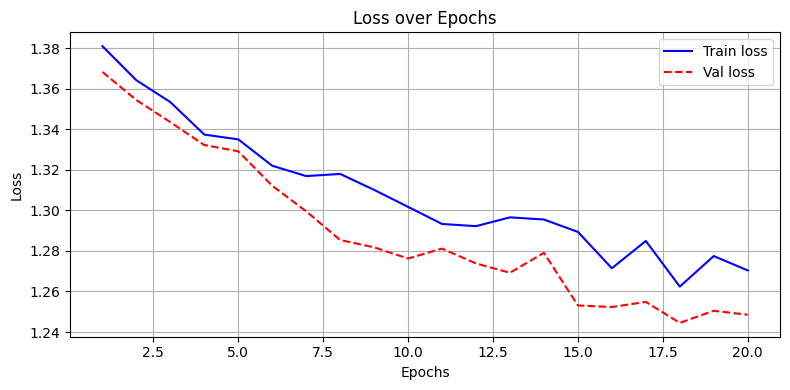

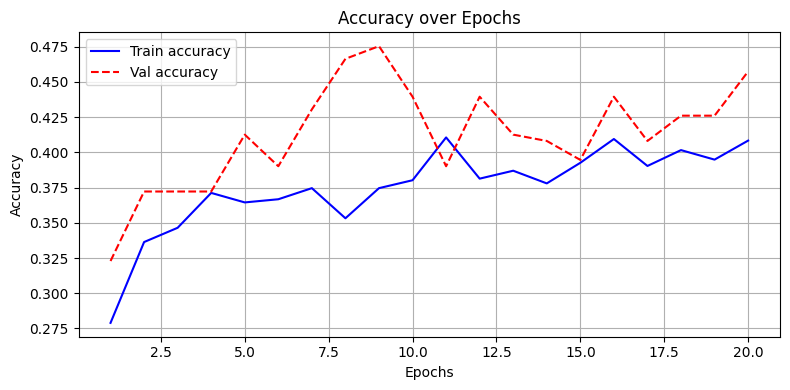

In [53]:
plot_training_history(snapshot_space_history, metrics=['loss', 'accuracy'])

In [54]:
from scipy.stats import mode

def predict_full_sequence(model, data, method = 'space', time_per_snapshot=32, agg='mean'):
    snapshots = extract_snapshots(data, method = method, time_per_snapshot = time_per_snapshot)
    probs = model.predict(snapshots)

    if agg == 'mean':
        return int(np.argmax(np.mean(probs, axis=0)))
    elif agg == 'vote':
        preds = np.argmax(probs, axis=1)
        return int(mode(preds).mode[0])


In [55]:
X_sequences = [rest_data, motor_data, story_math_data, wm_data]
y_true = [0, 1, 2, 3]  # true labels corresponding to above

y_pred = [predict_full_sequence(snapshot_model_space, seq, method = 'space') for seq in X_sequences]
print("Accuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("Snapshot validation accuracy:", snapshot_model_space.evaluate(X_val, y_val)[1])
print("Sequence aggregated accuracy:", accuracy_score(y_true, y_pred))


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        rest       1.00      1.00      1.00         1
       motor       1.00      1.00      1.00         1
  story_math       1.00      1.00      1.00         1
          wm       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix:
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4617 - loss: 1.2544 
Snapshot validation accuracy: 0.4573991000652313
Sequence aggregated accuracy: 1.0


# Testing

In [56]:
# intra 1
participant_id_intra = 105923
rest_intra, motor_intra, story_math_intra, wm_intra = load_participant_arrays(participant_id_intra, base_dir=r"/content/drive/MyDrive/DL part 2/Final Project data/Intra/test")


print("Rest:", None if rest_intra is None else rest_intra.shape)
print("Motor:", None if motor_intra is None else motor_intra.shape)
print("Story/Math:", None if story_math_intra is None else story_math_intra.shape)
print("Working Memory:", None if wm_intra is None else wm_intra.shape)


Rest: (248, 71248)
Motor: (248, 71248)
Story/Math: (248, 71248)
Working Memory: (248, 71248)


In [57]:
test_datasets = [rest_intra, motor_intra, story_math_intra, wm_intra]
task_names = ["rest", "motor", "story_math", "wm"]

# preprocessing all datasets
preprocessed_testdatasets=[]

for data, (mean, std) in zip(test_datasets, norm_values):
  arr = preprocess_meg_testdata(
        data,
        mean,
        std,
        downsample_method="decimate",
        target_rate=64,
        orig_rate=2034
    )
  preprocessed_testdatasets.append(arr)


# reorder and store data per task
reordered_testdata_dict = {}
sensor_testorder_dict = {}
cluster_testlabels_dict = {}

for data, name in zip(preprocessed_testdatasets, task_names):
    reordered_testdata = data[sensor_order, :]
    reordered_testdata_dict[f"reordered_data_{name}"] = reordered_testdata
    sensor_testorder_dict[f"sensor_order_{name}"] = sensor_order
    cluster_testlabels_dict[f"cluster_labels_{name}"] = cluster_labels


In [58]:
rest_data = reordered_testdata_dict["reordered_data_rest"]
rest_sensor_order = sensor_testorder_dict["sensor_order_rest"]
rest_clusters = cluster_testlabels_dict["cluster_labels_rest"]

motor_data = reordered_testdata_dict["reordered_data_motor"]
motor_sensor_order = sensor_testorder_dict["sensor_order_motor"]
motor_clusters = cluster_testlabels_dict["cluster_labels_motor"]

story_math_data = reordered_testdata_dict["reordered_data_story_math"]
story_math_sensor_order = sensor_testorder_dict["sensor_order_story_math"]
story_math_clusters = cluster_testlabels_dict["cluster_labels_story_math"]

wm_data = reordered_testdata_dict["reordered_data_wm"]
wm_sensor_order = sensor_testorder_dict["sensor_order_wm"]
wm_clusters = cluster_testlabels_dict["cluster_labels_wm"]

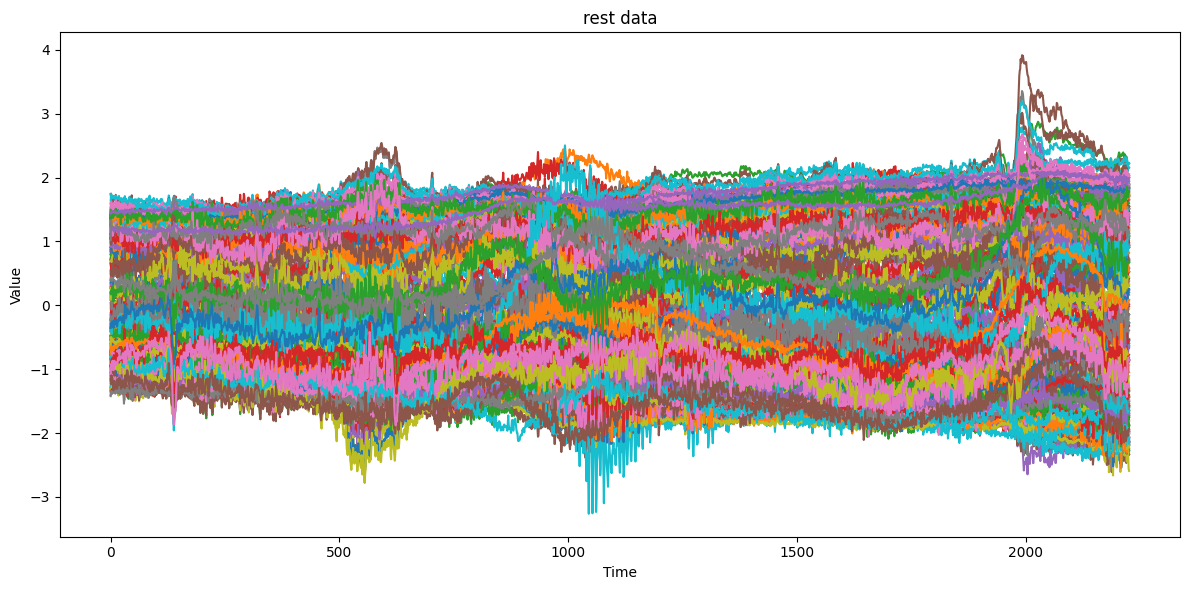

In [59]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(rest_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("rest data")
plt.tight_layout()
plt.show()

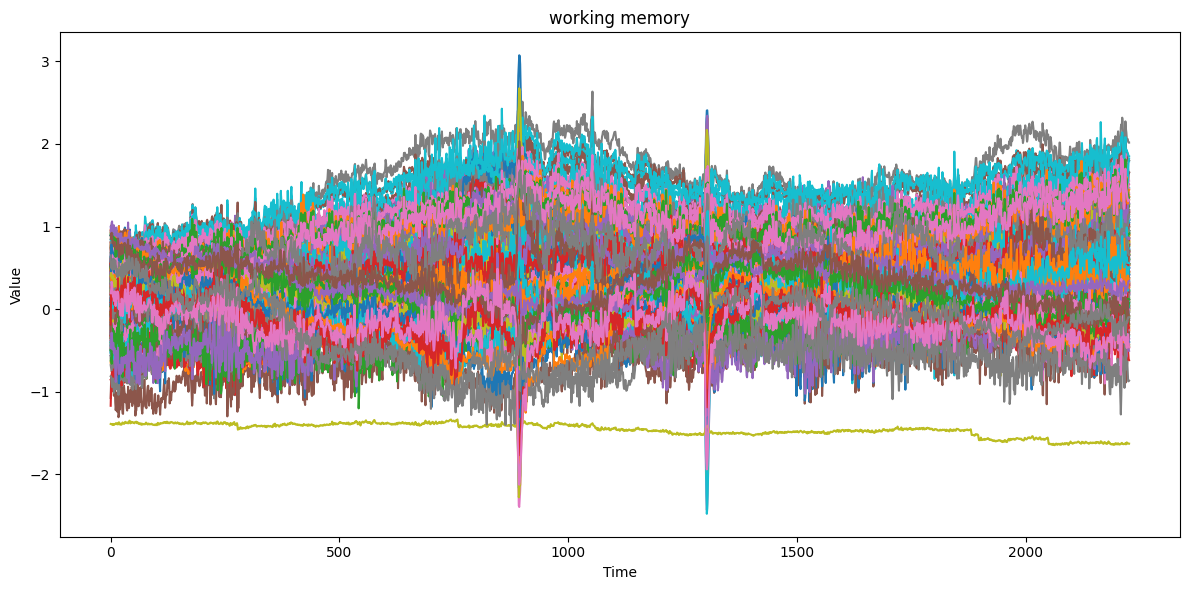

In [60]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(wm_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("working memory")
plt.tight_layout()
plt.show()

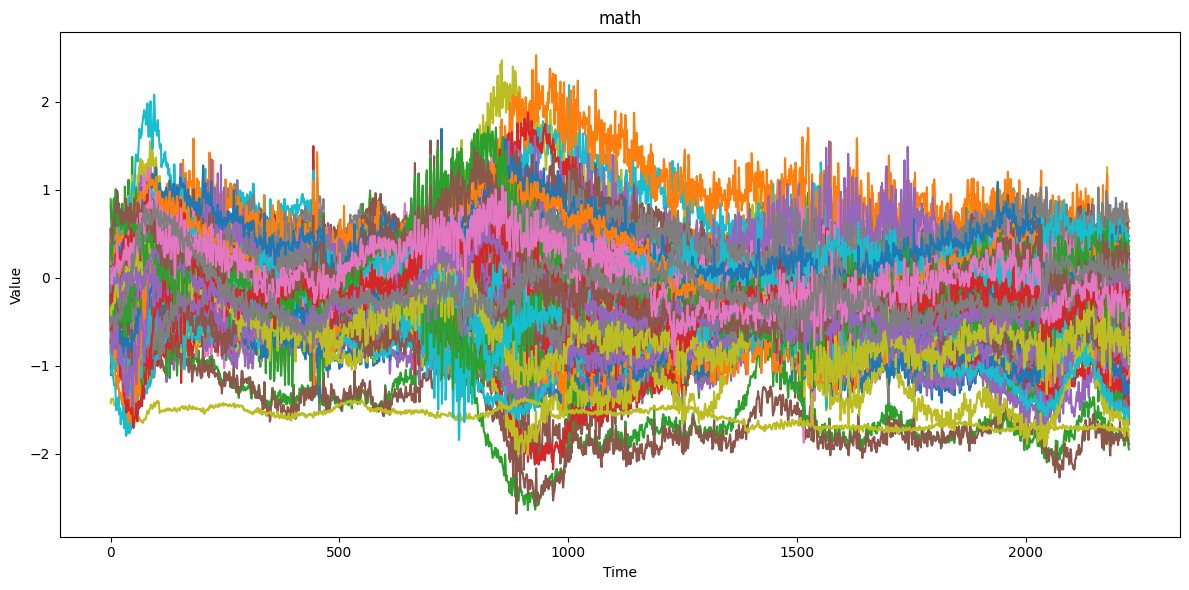

In [61]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(story_math_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("math")
plt.tight_layout()
plt.show()

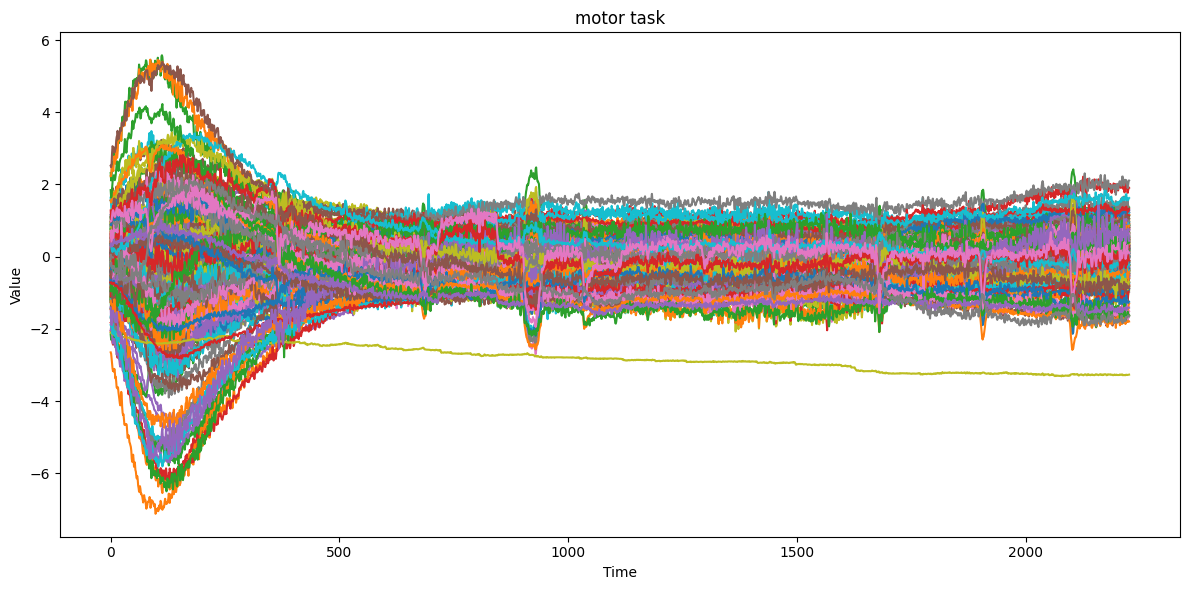

In [62]:
plt.figure(figsize=(12, 6))
for i in range(248):  # You can increase this to show more rows
    plt.plot(motor_data[i], label=f"Row {i}")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("motor task")
plt.tight_layout()
plt.show()

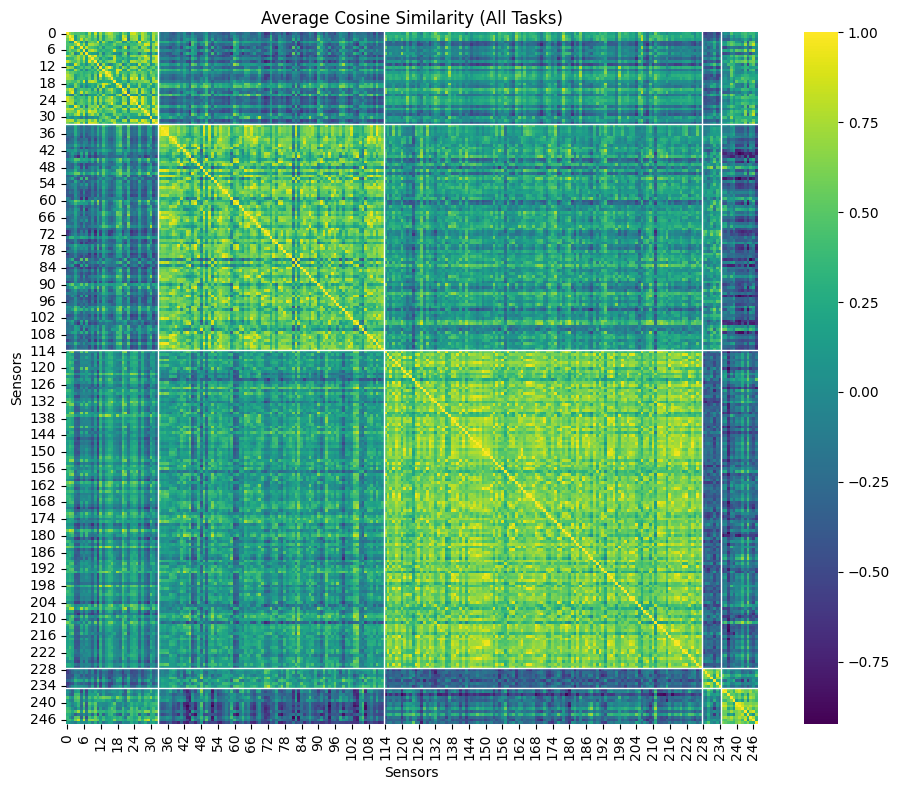

In [63]:
plot_avg_sensor_similarity(
    sim_matrix=avg_sim_matrix,
    sensor_order=sensor_order,
    cluster_labels=cluster_labels,
    title="Average Cosine Similarity (All Tasks)"
)

# Time aggregated

In [64]:
# Predicting on the test data
X_test_sequences = [rest_data, motor_data, story_math_data, wm_data]
y_test_true = [0, 1, 2, 3]  # True labels in order

y_test_pred = [predict_full_sequence(snapshot_model, seq, method='time') for seq in X_test_sequences]

# Print Results
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Test Accuracy:", accuracy_score(y_test_true, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test_true, y_test_pred, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_true, y_test_pred))
#print("Snapshot validation accuracy:", snapshot_model.evaluate(X_val, y_val)[1])
#print("Sequence aggregated accuracy:", accuracy_score(y_test_true, y_test_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Test Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

        rest       1.00      1.00      1.00         1
       motor       1.00      1.00      1.00         1
  story_math       1.00      1.00      1.00         1
          wm       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix:
 [[1 0 0 0]
 [0 1 0 0]
 [0 0 1 0]
 [0 0 0 1]]


In [65]:
from sklearn.metrics import accuracy_score

print("=== Snapshot Accuracy (Time Aggregation) ===")
for task_name, data in {
    "rest": rest_data,
    "motor": motor_data,
    "story_math": story_math_data,
    "wm": wm_data
}.items():
    snapshots = extract_snapshots(data, method='time')
    predictions = snapshot_model.predict(snapshots)
    labels = np.argmax(predictions, axis=1)
    true_labels = [label_map[task_name]] * len(labels)
    print(true_labels)
    print(labels)
    acc = accuracy_score(true_labels, labels)
    print(f"{task_name.capitalize():<12}: {acc:.4f}")



=== Snapshot Accuracy (Time Aggregation) ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Rest        : 1.0000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1 3 3 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Motor       : 0.9710
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

# Space aggregation

In [66]:
y_test_pred_space = [predict_full_sequence(snapshot_model_space, seq, method='space') for seq in X_test_sequences]

print("Test Accuracy (space):", accuracy_score(y_test_true, y_test_pred_space))
print("\nClassification Report:\n", classification_report(y_test_true, y_test_pred_space, target_names=label_map.keys()))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_true, y_test_pred_space))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Test Accuracy (space): 0.5

Classification Report:
               precision    recall  f1-score   support

        rest       0.00      0.00      0.00         1
       motor       0.00      0.00      0.00         1
  story_math       0.50      1.00      0.67         1
          wm       0.50      1.00      0.67         1

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4


Confusion Matrix:
 [[0 0 0 1]
 [0 0 1 0]
 [0 0 1 0]
 [0 0 0 1]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [67]:
print("\n=== Snapshot Accuracy (Space Aggregation) ===")
for task_name, data in {
    "rest": rest_data,
    "motor": motor_data,
    "story_math": story_math_data,
    "wm": wm_data
}.items():
    snapshots = extract_snapshots(data, method='space')
    predictions = snapshot_model_space.predict(snapshots)
    labels = np.argmax(predictions, axis=1)
    true_labels = [label_map[task_name]] * len(labels)
    acc = accuracy_score(true_labels, labels)
    print(f"{task_name.capitalize():<12}: {acc:.4f}")



=== Snapshot Accuracy (Space Aggregation) ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Rest        : 0.8551
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Motor       : 0.1304
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Story_math  : 0.6522
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Wm          : 0.6087
